# **수열의 극한**

a_10 = 1.6153846153846154 = 1.6154
a_100 = 1.9514563106796117 = 1.9515
a_1000 = 1.9950149551345961 = 1.9950
a_10000 = 1.9995001499550136 = 1.9995
a_100000 = 1.999950001499955 = 2.0000

일반항: a_n = (2*n + 1)/(n + 3)
lim(n→∞) a_n = 2
n → ∞ 이면 1/n → 0 이므로 a_n → 2 로 수렴한다.


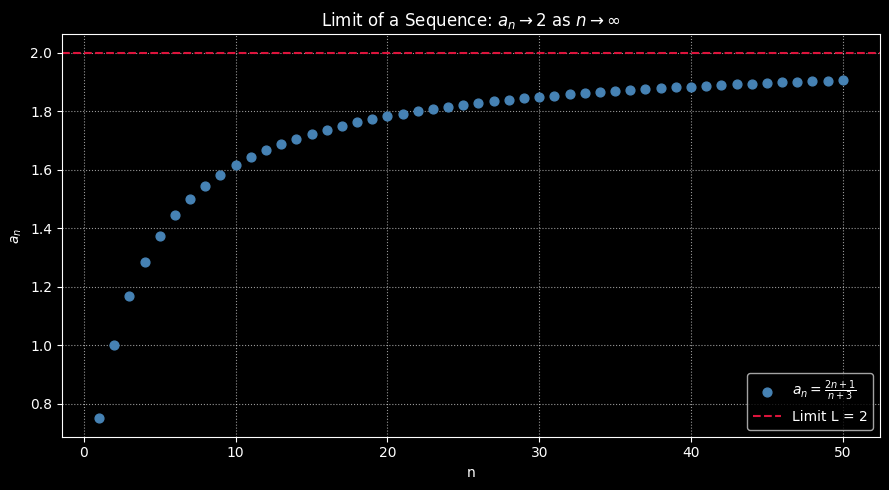

In [ ]:
import sympy as sp
import matplotlib.pyplot as plt

n = sp.symbols('n', integer=True, positive=True)


def a_n(n):
    return (2 * n + 1) / (n + 3)

for k in [10, 100, 1000, 10000, 100000]:
    val = a_n(k)
    print(f'a_{k} = {val} = {float(val):.4f}')

# 일반항 (n에 대한 식)
term = a_n(n)
print(f'\n일반항: a_n = {term}')

limit_val = sp.limit(term, n, sp.oo)
print(f'lim(n→∞) a_n = {limit_val}')

if limit_val == 2:
    print('n → ∞ 이면 1/n → 0 이므로 a_n → 2 로 수렴')

# 시각화: n이 커질수록 a_n이 극한값 2에 가까워짐
ns = list(range(1, 51))
vals = [float(a_n(k)) for k in ns]

plt.figure(figsize=(9, 5))
plt.scatter(ns, vals, s=40, color='steelblue', zorder=3, label=r'$a_n = \frac{2n+1}{n+3}$')
plt.axhline(float(limit_val), color='crimson', linestyle='--', linewidth=1.5,
            label=f'Limit L = {limit_val}')
plt.xlabel('n')
plt.ylabel(r'$a_n$')
plt.title(r'Limit of a Sequence: $a_n \to 2$ as $n \to \infty$')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



# **등비수열의 극한**

a_1 = 3

r =  0.5: lim = 0  |  Converges to 0
         reason: |r| < 1  ->  r^(n-1) -> 0

r =    1: lim = 3  |  Converges to a_1
         reason: r = 1  -> equal a_1

r =    2: lim = oo  |  Diverges to +inf
         reason: r > 1  ->  diverges to +inf

r =   -1: lim = No single limit (AccumBounds(-3, 3))  |  No limit (oscillation)
         reason: r = -1  ->  oscillates, no limit

r =   -2: lim = No single limit (AccumBounds(-oo, oo))  |  No limit (oscillation)
         reason: r < -1  ->  oscillates with growing magnitude, no limit



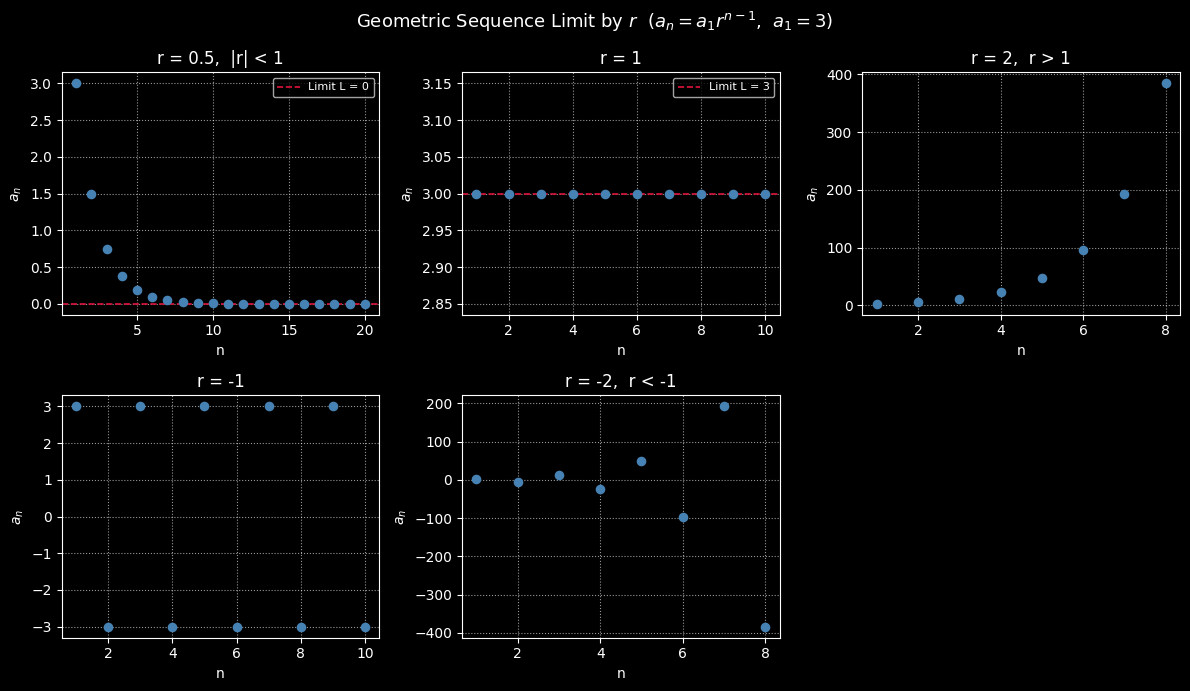

In [ ]:
from sympy.calculus.accumulationbounds import AccumBounds
from sympy.series.limitseq import limit_seq

a1 = 3


def geo_a_n(a1, r, k):
    return a1 * r ** (k - 1)


def geo_limit_case(a1, r):
    if abs(r) < 1:
        return 0, '|r| < 1  ->  r^(n-1) -> 0'
    elif r == 1:
        return a1, 'r = 1  -> equal a_1'
    elif r == -1:
        return None, 'r = -1  ->  oscillates, no limit'
    elif r > 1:
        sign = '+inf' if a1 > 0 else '-inf'
        return sp.oo if a1 > 0 else -sp.oo, f'r > 1  ->  diverges to {sign}'
    else:
        return None, 'r < -1  ->  oscillates with growing magnitude, no limit'


def format_limit(cal):
    if isinstance(cal, AccumBounds):
        return f'No single limit ({cal})'
    return str(cal)


cases = [
    (0.5,  'Converges to 0'),
    (1,    'Converges to a_1'),
    (2,    'Diverges to +inf'),
    (-1,   'No limit (oscillation)'),
    (-2,   'No limit (oscillation)'),
]

print(f'a_1 = {a1}\n')
for r_val, desc in cases:
    term = a1 * r_val ** (n - 1)
    cal = limit_seq(term, n)
    _, reason = geo_limit_case(a1, r_val)
    print(f'r = {r_val:>4}: lim = {format_limit(cal)}  |  {desc}')
    print(f'         reason: {reason}\n')

plot_cases = [
    (0.5, 20, 'r = 0.5,  |r| < 1'),
    (1,   10, 'r = 1'),
    (2,    8, 'r = 2,  r > 1'),
    (-1,  10, 'r = -1'),
    (-2,   8, 'r = -2,  r < -1'),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for ax, (r_val, n_max, title) in zip(axes, plot_cases):
    ns = list(range(1, n_max + 1))
    vals = [geo_a_n(a1, r_val, k) for k in ns]
    ax.scatter(ns, vals, s=35, color='steelblue', zorder=3)

    expected, _ = geo_limit_case(a1, r_val)
    if expected is not None and expected in (0, a1):
        ax.axhline(float(expected), color='crimson', linestyle='--', linewidth=1.2,
                   label=f'Limit L = {expected}')
        ax.legend(loc='best', fontsize=8)

    ax.set_title(title)
    ax.set_xlabel('n')
    ax.set_ylabel(r'$a_n$')
    ax.grid(True, linestyle=':', alpha=0.6)

axes[-1].axis('off')
fig.suptitle(r'Geometric Sequence Limit by $r$  ($a_n = a_1 r^{n-1}$,  $a_1=3$)', fontsize=13)
plt.tight_layout()
plt.show()